In [25]:
import lbforaging
import numpy as np
import time
import matplotlib.pyplot as plt

from games.foraging import Foraging
from agents.iql import IndependentQLearning

In [26]:
game_config = [
        "Foraging-5x5-2p-1f-v3",
        "Foraging-8x8-2p-1f-v3",
        "Foraging-8x8-3p-1f-v3",
        "Foraging-8x8-3p-1f-coop-v3",
    ]

In [27]:
def epsilon_decay(max_t, min_eps=0.01):
    """Compute per-step decay so epsilon reaches min_eps after max_t steps."""
    return min_eps ** (1 / max_t)

configurations = {
    '0' : {
        'game': game_config[0],
        # 100 eps * 10 iters * ~50 steps/ep = ~50000 steps; decay over first half
        'iql': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 10},
    },
    '1' : {
        'game': game_config[1],
        'iql': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 50},
    },
    '2' : {
        'game': game_config[2],
        'iql': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 100},
    },
    '3' : {
        'game': game_config[3],
        'iql': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'train_config': {'episodes': 1000, 'iterations': 100},
    },
}

In [28]:
config = configurations['3']
game = Foraging(config=config['game'], seed=1)
agents = {agent: IndependentQLearning(game=game, agent=agent, **config['iql']) for agent in game.agents}

In [29]:
game.reset()
for agent in game.agents:
    print(f"Agent: {agent}")
    print(f"Observation: {game.observe(agent)}")

Agent: agent_0
Observation: [5. 2. 4. 0. 1. 2. 7. 1. 1. 6. 3. 1.]
Agent: agent_1
Observation: [5. 2. 4. 7. 1. 1. 0. 1. 2. 6. 3. 1.]
Agent: agent_2
Observation: [5. 2. 4. 6. 3. 1. 0. 1. 2. 7. 1. 1.]


In [30]:
def play_episode(game, agents, verbose=False, render=False):

    # Initialize the game
    game.reset()
    step_count = 0

    # Reset each agent's episode state (keeps Q-table across episodes)
    for agent in game.agents:
        agents[agent].reset()

    # Print initial observations if verbose is enabled
    if verbose:
        print(f"Step: {step_count}")
        for agent in game.agents:
            print(f"Agent {agent} observe: {game.observe(agent)}")

    # Initialize rewards for each agent
    cum_rewards = dict(map(lambda agent: (agent, 0.0), game.agents))

    # render the game if required
    if render:
        game.render()
        time.sleep(0.5)

    while not game.done():

        step_count += 1
        
        # Get actions; action() internally calls update() to learn from the previous step
        actions = {}
        for agent in game.agents:
            actions[agent] = agents[agent].action()
             
        # Perform the actions in the game
        game.step(actions)

        # Update the cum_rewards for each agent
        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)

        # Print actions, rewards and next state if verbose is enabled
        if verbose:
            print(f"Step: {step_count}")
            for agent in game.agents:
                    print(f"Agent {agent} action: {actions[agent]} - {game.action_set[actions[agent]]}")
                    print(f"Agent {agent} reward: {game.reward(agent)}")
                    print(f"Agent {agent} observe: {game.observe(agent)}")
            
        if render:
            game.render()
            time.sleep(0.5)
    
    # Process the terminal reward (last transition not yet seen by action())
    for agent in game.agents:
        agents[agent].update()
    
    return cum_rewards

In [31]:
def run(game, agents, episodes=1, verbose=False, render=False):
    sum_rewards = dict(map(lambda agent: (agent, 0.0), game.agents))
    for _ in range(episodes):
        cum_rewards = play_episode(game, agents, verbose=verbose, render=render)  
        for agent in game.agents:
            sum_rewards[agent] += cum_rewards[agent]
    if verbose:
        print(f"Average rewards over {episodes} episodes:")
        for agent in game.agents:
            print(f"Agent {agent}: {sum_rewards[agent] / episodes}")  
    return sum_rewards     

In [32]:
def train(game, agents, train_config, progress=False, verbose=False, render=False):
    iterations = train_config["iterations"]
    episodes = train_config["episodes"]
    average_rewards = dict(map(lambda agent: (agent, []), game.agents))
    for i in range(1, iterations+1):
        sum_rewards = run(game, agents, episodes=episodes, verbose=False, render=False)
        for agent in game.agents:
            average_rewards[agent].append(sum_rewards[agent] / episodes)
        if progress and (i % 10 == 0):
            print(f"Iteration {i} ({i * episodes} episodes)")
            for agent in game.agents:
                print(f"Agent {agent}: {average_rewards[agent][-1]}")
    if progress:
        print(f"Last average rewards over {iterations} iterations ({iterations * episodes} episodes):")
        for agent in game.agents:
            print(f"Agent {agent}: {average_rewards[agent][-1]}")
    return average_rewards

In [33]:
average_rewards = train(game, agents, train_config=config['train_config'], progress=True, verbose=False, render=False)

Iteration 10 (10000 episodes)
Agent agent_0: 0.431
Agent agent_1: 0.2155
Agent agent_2: 0.2155
Iteration 20 (20000 episodes)
Agent agent_0: 0.476
Agent agent_1: 0.238
Agent agent_2: 0.238
Iteration 30 (30000 episodes)
Agent agent_0: 0.49
Agent agent_1: 0.245
Agent agent_2: 0.245
Iteration 40 (40000 episodes)
Agent agent_0: 0.495
Agent agent_1: 0.2475
Agent agent_2: 0.2475
Iteration 50 (50000 episodes)
Agent agent_0: 0.4925
Agent agent_1: 0.24625
Agent agent_2: 0.24625
Iteration 60 (60000 episodes)
Agent agent_0: 0.4965
Agent agent_1: 0.24825
Agent agent_2: 0.24825
Iteration 70 (70000 episodes)
Agent agent_0: 0.4995
Agent agent_1: 0.24975
Agent agent_2: 0.24975
Iteration 80 (80000 episodes)
Agent agent_0: 0.4995
Agent agent_1: 0.24975
Agent agent_2: 0.24975
Iteration 90 (90000 episodes)
Agent agent_0: 0.499
Agent agent_1: 0.2495
Agent agent_2: 0.2495
Iteration 100 (100000 episodes)
Agent agent_0: 0.4985
Agent agent_1: 0.24925
Agent agent_2: 0.24925
Last average rewards over 100 iteratio

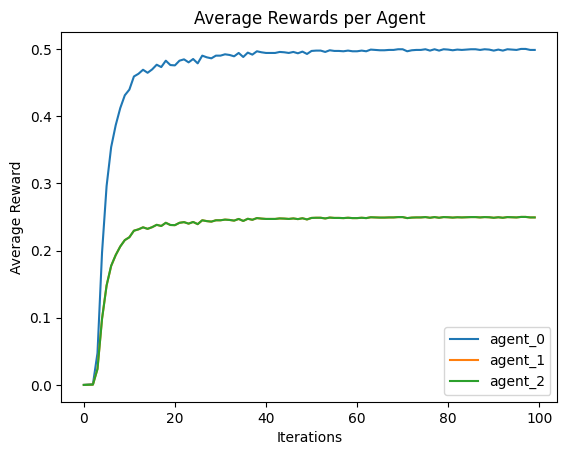

In [34]:
for agent, rewards in average_rewards.items():
    plt.plot(rewards, label=agent)

plt.xlabel('Iterations')
plt.ylabel('Average Reward')
plt.title('Average Rewards per Agent')
plt.legend()
plt.show()

In [35]:
for agent in game.agents:
    agents[agent].epsilon = 0.0
    agents[agent].alpha = 0.0

In [36]:
play_episode(game, agents, verbose=True, render=False)

Step: 0
Agent agent_0 observe: [5. 2. 4. 0. 1. 2. 7. 1. 1. 6. 3. 1.]
Agent agent_1 observe: [5. 2. 4. 7. 1. 1. 0. 1. 2. 6. 3. 1.]
Agent agent_2 observe: [5. 2. 4. 6. 3. 1. 0. 1. 2. 7. 1. 1.]
Step: 1
Agent agent_0 action: 3 - WEST
Agent agent_0 reward: 0
Agent agent_0 observe: [5. 2. 4. 0. 0. 2. 7. 0. 1. 6. 2. 1.]
Agent agent_1 action: 3 - WEST
Agent agent_1 reward: 0
Agent agent_1 observe: [5. 2. 4. 7. 0. 1. 0. 0. 2. 6. 2. 1.]
Agent agent_2 action: 3 - WEST
Agent agent_2 reward: 0
Agent agent_2 observe: [5. 2. 4. 6. 2. 1. 0. 0. 2. 7. 0. 1.]
Step: 2
Agent agent_0 action: 3 - WEST
Agent agent_0 reward: 0
Agent agent_0 observe: [5. 2. 4. 0. 0. 2. 7. 0. 1. 6. 1. 1.]
Agent agent_1 action: 3 - WEST
Agent agent_1 reward: 0
Agent agent_1 observe: [5. 2. 4. 7. 0. 1. 0. 0. 2. 6. 1. 1.]
Agent agent_2 action: 3 - WEST
Agent agent_2 reward: 0
Agent agent_2 observe: [5. 2. 4. 6. 1. 1. 0. 0. 2. 7. 0. 1.]
Step: 3
Agent agent_0 action: 1 - NORTH
Agent agent_0 reward: 0
Agent agent_0 observe: [5. 2. 4. 

{'agent_0': 0.5, 'agent_1': 0.25, 'agent_2': 0.25}